# Lecture 2 Exercises



## Short Questions

<font size = "5">

1. How do you check whether an element is part of a list?
2. How do you reference a global variable in ```.query()```?


In [1]:
# Write your answers here as comments:


# 1. You can check whether an element is part of a list using the `in` keyword. For example, if you have a list called `my_list` and you want to check if the element `x` is in that list, you would write:
# ```python
# x in my_list
# ```

# 2. To reference a global variable in `.query()`, you can use the `@` symbol before the variable name. For example, if you have a global variable called `my_variable`, you would reference it in `.query()` like this:
# ```python
# df.query('column_name == @my_variable')




## Long Questions

<font size = "5">

Import the pandas and matplotlib packages

In [2]:
# Write your own code

import pandas as pd
import matplotlib.pyplot as plt


<font size = "5">

(a) Checking a string condition

<font size = "3">

- Define a variable "fruit" with the value "apple"
- Define a list

list_fruits = ["banana","orange","apple"]
- Write an expression to test whether "fruit" is contained in "list_fruits"

Hint: Use the "in" command. The final output should be True/False.

To get full points run all of the above commands


In [5]:
# Write your own code

list_fruits = ["banana", "orange", "apple"]

fruit = "apple"

print(fruit in list_fruits)


True


<font size = "5">

(b) Classifying a variable

<font size = "3">

- Define a new variable "year" an assign the value "2008"
- Write an if/else statement that does the following
    - print("Year 2000 or earlier") if the year is less than or equal to  2000.
    - print("Between 2001 and 2005") if the year is between 2001 and 2005.
    - print("Year 2006 or later") if the year is after 2005.

To get full points you must do all of the above instructions


In [7]:
# Write your own code

year = 2008
if year <= 2000:
    print("Year 2000 or earlier")
elif year >= 2001 and year <= 2005:
    print("Between 2001 and 2005")
else:
    print("Year 2006 or later")





Year 2006 or later


<font size = "5">

(c) Split a dataset into subsets

<font size = "3">

- Import the "features.csv" file as a pandas dataframe called "data"
- Create ``` list_status = [0,1]```
- Create ``` list_prob = [0.5, 0.5]```
- Create a new variable $n = 1000$ with the number of rows of the dataset
- Use 
```python
    np.random.choice(list_status,
                     size = n,
                     p = list_prob)
```
$\qquad$ to create a new column called "status" <br>
$\qquad$ which randomly assigns each row to "0" or "1" <br>
$\qquad$ with equal probability
- Use .query() to subset all observations with status == 0.<br>
store it in a new dataset called "data0"
- Use .query() to subset all observations with status == 1.<br>
store it in a new dataset called "data1"



In [11]:
import numpy as np
from pathlib import Path

# Write your own code

file_path = Path("features.csv")
if not file_path.exists():
    file_path = Path("data_raw/features.csv")

data = pd.read_csv(file_path)

list_status = [0, 1]
list_prob = [0.5, 0.5]
n = len(data)

data["status"] = np.random.choice(
    list_status,
    size=n,
    p=list_prob
)

data0 = data.query("status == 0")
data1 = data.query("status == 1")



<font size = "5">

For questions (d) through (f) mport the dataset <br>
 "data_raw/fifa23_players_basic.csv"

<font size = "3">

- It's a dataset on professional soccer players
- Rows correspond to players (18,539)
- Columns contain attributes of players (32)
- Try to view the dataset before starting

In [12]:
# Write your own code

data = pd.read_csv("data_raw/fifa23_players_basic.csv")



<font size = "5">

(d) Create a new dataset subsetting the <br>
players whose age is less than 20

In [31]:
# Write your own code

subset = data[data["Age"] < 20]

print(subset)


            Known As             Full Name  Overall  Potential  \
82             Pedri  Pedro González López       85         93   
124    J. Bellingham       Jude Bellingham       84         91   
225         F. Wirtz         Florian Wirtz       82         91   
302       J. Musiala         Jamal Musiala       81         90   
527        Ansu Fati        Anssumane Fati       79         90   
...              ...                   ...      ...        ...   
18530         S. Bag             Sajal Bag       48         61   
18533      Pi Ziyang             Ziyang Pi       47         60   
18535   Yang Dejiang          Dejiang Yang       47         57   
18536      L. Mullan           Liam Mullan       47         67   
18537   D. McCallion      Daithí McCallion       47         61   

       Value(in Euro) Positions Played Best Position          Nationality  \
82          116000000               CM            CM                Spain   
124          81500000            CM,LM            CM 

<font size = "5">

(e) Use queries + global variables

<font size = "3">

- Compute the mean of the column "Value(in Euro)" <br>
and store it as a variable
- Subset the players whose value is above the mean value <br>
  using ".query()"


HINT: Remember that there is a special syntax for <br>
when the column names have spaces (see Lecture 10) <br>
Reference the column as ``` `Value(in Euro)`    ``` inside .query()

In [30]:
# Write your own code


from sqlalchemy import column, create_engine, select, Table, MetaData

mean_value = data["Value(in Euro)"].mean()
subset = data.query("`Value(in Euro)` > @mean_value")

print(subset)
    

            Known As           Full Name  Overall  Potential  Value(in Euro)  \
0           L. Messi        Lionel Messi       91         91        54000000   
1         K. Benzema       Karim Benzema       91         91        64000000   
2     R. Lewandowski  Robert Lewandowski       91         91        84000000   
3       K. De Bruyne     Kevin De Bruyne       91         91       107500000   
4          K. Mbappé       Kylian Mbappé       91         95       190500000   
...              ...                 ...      ...        ...             ...   
7066       F. Rieder       Fabian Rieder       68         83         2900000   
7071     J. Bakayoko      Johan Bakayoko       68         85         3100000   
7090        M. Arezo        Matías Arezo       68         81         2900000   
7096       Y. Kallon        Yayah Kallon       68         82         3000000   
7168        M. Soulé        Matías Soulé       68         85         3100000   

     Positions Played Best Position   N

<font size = "5">

(f) Use sorting + ".iloc[]"

<font size = "3">

- Use ".sort_values()" to order the "Age" column <br>
from youngest to oldest
- Get a subset with the 5 youngest players

In [29]:
# Write your own code

data_sorted = data.sort_values("Age")
subset = data_sorted.head(5)

print(subset)

          Known As         Full Name  Overall  Potential  Value(in Euro)  \
18425    M. Moraru      Matei Moraru       50         72          150000   
18232    B. Faraas   Benjamin Faraas       51         76          180000   
18284   D. Lipsiuc    Darius Lipsiuc       51         65          130000   
18014    J. Ardila       José Ardila       53         73          250000   
16880  M. Kowalski  Mateusz Kowalski       56         75          350000   

      Positions Played Best Position          Nationality  \
18425            CM,RW           CAM              Romania   
18232               CM           CAM               Norway   
18284              CAM           CAM  Republic of Ireland   
18014               CM           CAM            Venezuela   
16880               ST            ST               Poland   

                                             Image Link  Age  ...  \
18425  https://cdn.sofifa.net/players/271/182/23_60.png   16  ...   
18232  https://cdn.sofifa.net/players/

<font size = "5">
For questions (h)-(i), read "data_raw/wdi_2020.csv" <br>
This is a dataset of countries from <br>
the World Development Indicators

<font size = "5">

(g) Extract sorted elements from a dataset

<font size = "3">

- Sort by "prop_urbanpopulation" in descending order
- Subset the 5 countries with the highest urban population

In [28]:
# Write your own code

data2 = pd.read_csv("data_raw/wdi_2020.csv")

data_sorted = data2.sort_values("prop_urbanpopulation", ascending=False)
subset = data_sorted.head(5)
print(subset)


     year yearcode                countryname countrycode  \
213  2020   YR2020  Sint Maarten (Dutch part)         SXM   
24   2020   YR2020                    Bermuda         BMU   
103  2020   YR2020       Hong Kong SAR, China         HKG   
90   2020   YR2020                  Gibraltar         GIB   
212  2020   YR2020                  Singapore         SGP   

     prop_urbanpopulation  
213                 100.0  
24                  100.0  
103                 100.0  
90                  100.0  
212                 100.0  


<font size = "5">

(h) Subset elements with query

<font size = "3">

- Compute the median of "prop_urbanpopulation"
- Use ".query()" to subset countries with <br>
 "prop_urbanpopulation" above the median

In [32]:
# Write your own code


median_value = data2["prop_urbanpopulation"].median()
subset = data2.query("prop_urbanpopulation > @median_value")

print(subset)


     year yearcode            countryname countrycode  prop_urbanpopulation
3    2020   YR2020                Albania         ALB             62.112000
4    2020   YR2020                Algeria         DZA             73.733000
5    2020   YR2020         American Samoa         ASM             87.153000
6    2020   YR2020                Andorra         AND             87.916000
7    2020   YR2020                 Angola         AGO             66.825000
..    ...      ...                    ...         ...                   ...
254  2020   YR2020    Upper middle income         UMC             67.601442
255  2020   YR2020                Uruguay         URY             95.515000
258  2020   YR2020          Venezuela, RB         VEN             88.279000
260  2020   YR2020  Virgin Islands (U.S.)         VIR             95.939000
261  2020   YR2020     West Bank and Gaza         PSE             76.719000

[131 rows x 5 columns]


<font size = "5">

(i) Plot by category

<font size = "3">

- Read "data_raw/wdi_urban.csv"<br>
This contains data from 1980 and 2020

- Create a list with the unique values of "year"
- Create a plot with a ...
    - Histogram of "prop_urbanpopulation" <br>
    for each year
    - Set the histogram option ``` alpha = 0.5 ``` for transparency
    - All the histograms should be overlapping
    - Create a legend with the list of years
    - Label the axes and the title

What do we learn from the graph?

HINT: See the example at the end of Lecture 10


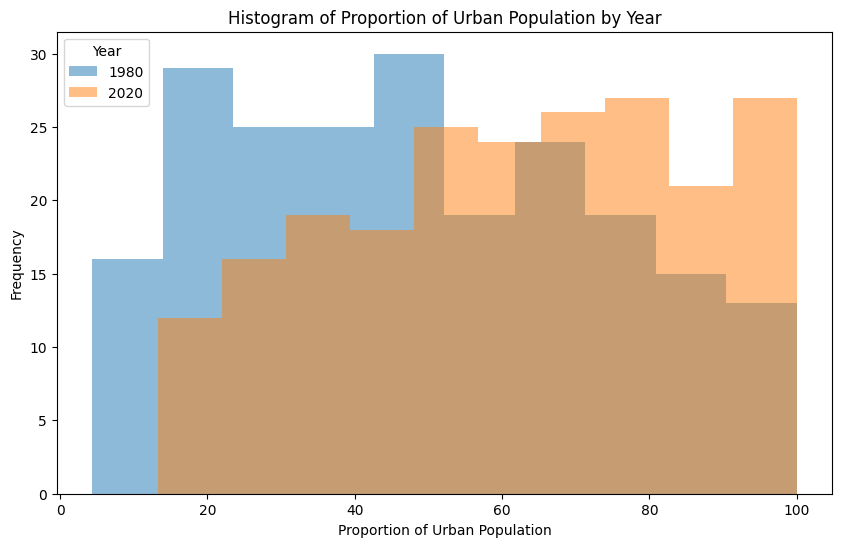

In [33]:
# Write your own code



data = pd.read_csv("data_raw/wdi_urban.csv")
years = data["year"].unique()
plt.figure(figsize=(10, 6))
for year in years:
    subset = data[data["year"] == year]
    plt.hist(subset["prop_urbanpopulation"], alpha=0.5, label=str(year))
plt.xlabel("Proportion of Urban Population")
plt.ylabel("Frequency")
plt.title("Histogram of Proportion of Urban Population by Year")
plt.legend(title="Year")
plt.show()

# The proportion of urban population has generally increased over the years, indicating a trend towards urbanization. The histogram shows that in earlier years, there were more countries with lower proportions of urban population, while in later years, the distribution shifts towards higher proportions, suggesting that more countries are becoming urbanized over time.

# Review of last lecture


<font size = "5">

(k) Composite operations on arrays

<font size = "3">

- Define $r = 0.04$
- Define two arrays $A$ and $T$ using "np.array()", assigning the following values

$ a = \begin{pmatrix} a_0 \\ a_1 \\ a_2 \end{pmatrix} =  \begin{pmatrix} 20 \\ 30 \\ 15 \end{pmatrix},
\qquad  t = \begin{pmatrix} t_0 \\ t_1 \\ t_2 \end{pmatrix} = \begin{pmatrix} 0 \\ 1 \\ 2 \end{pmatrix} $

- Use element-by-element vector operations to compute a new array $M$ of length 3:

$ M = \begin{pmatrix} a_1 / (1+r)^{t_0}  \\ a_2 / (1+r)^{t_1} \\ a_3 / (1+r)^{t_2} \end{pmatrix} $

- Compute the sum of the values of $M$ using "M.sum()"

Note: I am using subscripts to denote the individual elements of $a$ and $t$.
- In the code just enter the values of $a$ and $t$.
- To get full points you must do all of the above tasks



In [46]:
# Write your own code

from asyncio import tasks

r = 0.04
a = np.array([20, 30, 15])
t = np.array([0, 1, 2])
M = np.zeros(len(a))
for i in range(len(a)):
    M[i] = a[i] / (1 + r) ** t[i]
    print(f"Value of M for a={a[i]} and t={t[i]}: {M[i]}")
print(M)
sum_M = M.sum()
print(a)
print(t)
print(f"Sum of M: {sum_M}")


Value of M for a=20 and t=0: 20.0
Value of M for a=30 and t=1: 28.846153846153847
Value of M for a=15 and t=2: 13.86834319526627
[20.         28.84615385 13.8683432 ]
[20 30 15]
[0 1 2]
Sum of M: 62.71449704142012
